In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Chargement
df = pd.read_csv('../data/marketing_campaign.csv', sep=';')

# Analyse des valeurs manquantes, doublons et types
print(f"Nombre de lignes : {df.shape[0]}")
print(f"Doublons : {df.duplicated().sum()}")
print(f"Valeurs manquantes : \n{df.isnull().sum()[df.isnull().sum() > 0]}")

# Analyse des colonnes à variance nulle (variables inutiles)
print(f"Valeurs uniques Z_CostContact : {df['Z_CostContact'].nunique()}")
print(f"Valeurs uniques Z_Revenue : {df['Z_Revenue'].nunique()}")

df.info()

Nombre de lignes : 2240
Doublons : 0
Valeurs manquantes : 
Income    24
dtype: int64
Valeurs uniques Z_CostContact : 1
Valeurs uniques Z_Revenue : 1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   in

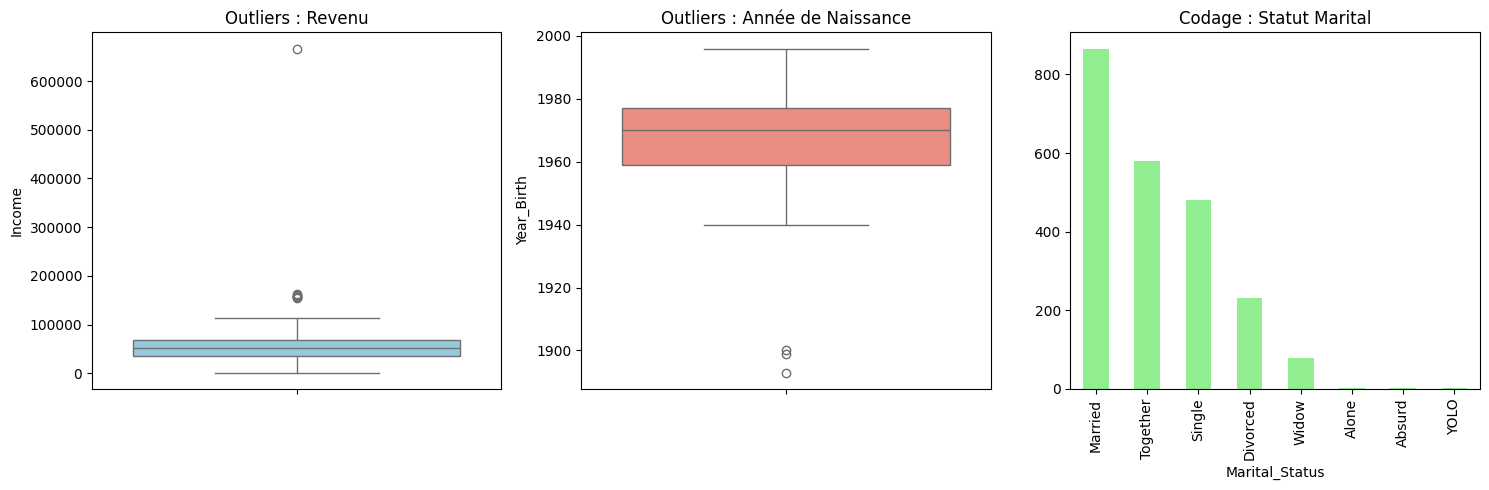

In [5]:
plt.figure(figsize=(15, 5))

# Visualisation des revenus
plt.subplot(1, 3, 1)
sns.boxplot(y=df['Income'], color='skyblue')
plt.title('Outliers : Revenu')

# Visualisation des dates de naissance
plt.subplot(1, 3, 2)
sns.boxplot(y=df['Year_Birth'], color='salmon')
plt.title('Outliers : Année de Naissance')

# Visualisation du statut marital (Anomalies de codage)
plt.subplot(1, 3, 3)
df['Marital_Status'].value_counts().plot(kind='bar', color='lightgreen')
plt.title('Codage : Statut Marital')

plt.tight_layout()
plt.show()

Stratégie de Nettoyage et Justifications Métier

Suite aux visualisations précédentes, nous avons identifié des points critiques qui pourraient fausser l'analyse multidimensionnelle et la future segmentation.

Traitement des valeurs manquantes et anomalies numériques

Revenu (Income) : Nous avons 24 valeurs manquantes. Plutôt que de supprimer ces clients, nous imputons la médiane
La distribution des revenus est asymétrique avec des valeurs extrêmes. La médiane est un indicateur de tendance centrale plus robuste que la moyenne dans ce contexte.

Âge (Year_Birth) : Suppression des individus nés avant 1940.
Les clients affichant plus de 82 ans (en 2022) présentent des profils de consommation incohérents avec le reste de la base, suggérant des erreurs de saisie.

Simplification des variables ambiguës

Variables à variance nulle : Suppression de Z_CostContact et Z_Revenue.
Ces colonnes contiennent la même valeur pour 100% des lignes. Elles n'apportent aucune information discriminante pour nos modèles d'IA ou nos rapports BI.

Statut Marital : Regroupement des catégories.
Les labels "Absurd", "YOLO" ou "Alone" sont nettoyés pour créer une dimension binaire : Seul vs En Couple, facilitant la lecture décisionnelle.

In [9]:
#Imputation du revenu
df['Income'] = df['Income'].fillna(df['Income'].median())

#Filtrage des outliers d'âge
df = df[df['Year_Birth'] > 1940]

#Suppression des colonnes inutiles identifiées lors de l'audit
df = df.drop(columns=['Z_CostContact', 'Z_Revenue'], errors='ignore')

#Harmonisation du statut marital (Transformation métier)
df['Living_With'] = df['Marital_Status'].replace({
    'Married':'Partner', 'Together':'Partner',
    'Absurd':'Alone', 'Widow':'Alone', 'YOLO':'Alone', 
    'Divorced':'Alone', 'Single':'Alone', 'Alone':'Alone'
})

#Conversion du type de donnée pour les dates
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='mixed', dayfirst=True)

print(f"Nettoyage terminé. Taille finale du dataset : {df.shape[0]} lignes.")

Nettoyage terminé. Taille finale du dataset : 2236 lignes.


In [ ]:
# Export du dataset nettoyé vers le dossier data
df.to_csv('../data/marketing_campaign_cleaned.csv', index=False)

Fichier sauvegardé avec succès dans le dossier data !


In [11]:
#Somme totale des dépenses (Le panier global)
products = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['Total_Spent'] = df[products].sum(axis=1)

#Nombre total d'enfants au foyer
df['Children_Home'] = df['Kidhome'] + df['Teenhome']

#Ancienneté du client (en jours par rapport à la fin du dataset, environ 2014-2015)
# Note : on utilise la date max du dataset pour simuler une analyse à l'instant T
reference_date = df['Dt_Customer'].max()
df['Seniority_Days'] = (reference_date - df['Dt_Customer']).dt.days

print("Variables stratégiques créées !")

Variables stratégiques créées !


Pour répondre aux objectifs de compréhension du portefeuille clients, j'ai choisi de ne pas me limiter aux variables brutes du dataset. En tant que futur Data Analyst, mon rôle est de transformer la donnée technique en information décisionnelle.

J'ai donc procédé à une étape de Feature Engineering pour créer des dimensions d'analyse plus parlantes pour une direction marketing :

Total_Spent (Indicateur de Valeur) : Agrégation des dépenses sur les 6 catégories de produits (Vin, Viande, Fruits, etc.). Cet indicateur est indispensable pour mesurer le Pouvoir d'achat global.

Children_Home (Dimension Foyer) : Somme des enfants et adolescents. Cela permet de simplifier la structure familiale en une seule variable numérique pour tester si la présence d'enfants est un signal discriminant.

Seniority_Days (Ancienneté) : Transformation de la date d'inscription en durée de relation client, permettant d'étudier la fidélité.

Ces nouvelles variables vont nous permettre d'aller au-delà de la simple statistique descriptive pour identifier les véritables leviers de performance.

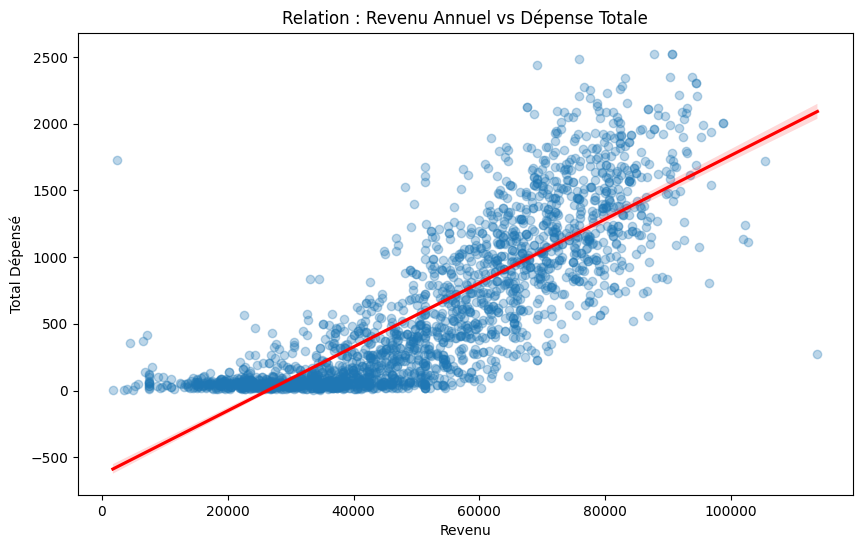

In [15]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df[df['Income'] < 150000], x='Income', y='Total_Spent', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Relation : Revenu Annuel vs Dépense Totale')
plt.xlabel('Revenu')
plt.ylabel('Total Dépensé')
plt.show()

Pour répondre à la problématique du lien entre le profil financier et le comportement d'achat, j'ai sélectionné un Scatter Plot (nuage de points) enrichi d'une droite de régression.

C'est le visuel le plus robuste pour identifier une corrélation entre deux variables continues. Il permet ici de visualiser la densité de la base clients et de détecter immédiatement les profils atypiques.

La droite de régression permet de confirmer statistiquement la tendance positive : une augmentation du revenu entraîne mécaniquement une hausse de la dépense globale.

Ici, on observe un phénomène de "dispense" : plus le revenu est élevé, plus les comportements divergent. Cela démontre que si le revenu est un moteur de dépense, il n'est pas le seul facteur explicatif. Ce constat justifie à lui seul le besoin d'une segmentation multidimensionnelle pour identifier d'autres leviers que le simple critère financier.

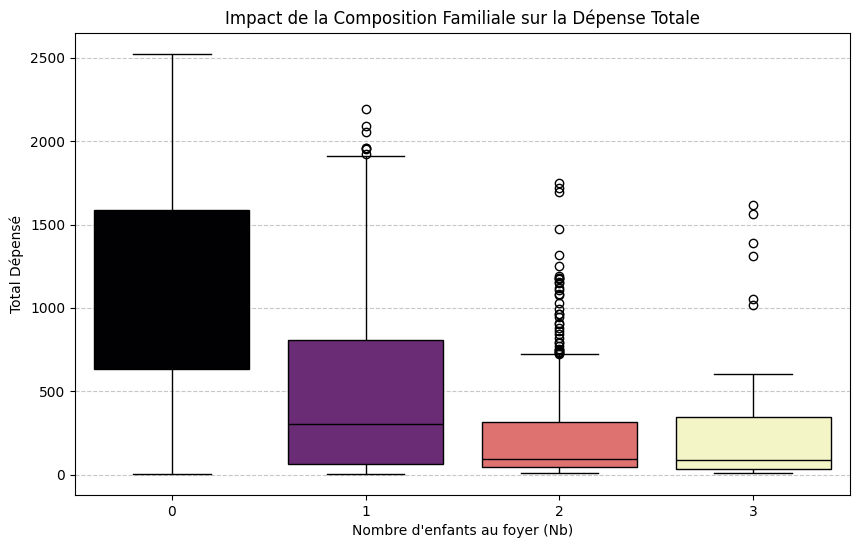

In [17]:
# Comparaison de la dépense totale selon le nombre d'enfants
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Children_Home', y='Total_Spent', hue='Children_Home', palette='magma', legend=False)

plt.title('Impact de la Composition Familiale sur la Dépense Totale')
plt.xlabel('Nombre d\'enfants au foyer (Nb)')
plt.ylabel('Total Dépensé')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Pour explorer la dimension "composition du foyer" demandée par l'énoncé, j'ai sélectionné un Boxplot.

Contrairement à un simple diagramme en barres qui ne montre que la moyenne, le Boxplot révèle la dispense et la médiane. C'est l'outil idéal pour comparer une variable numérique (Total_Spent) à travers les modalités d'une variable catégorielle (Children_Home).
Cela nous permet de voir instantanément si les groupes se ressemblent ou s'ils sont radicalement différents.

Ce graphique révèle le signal marketing le plus discriminant du dataset :

Rupture de consommation : On observe une chute brutale de la dépense médiane dès le premier enfant. Le segment "0 enfant" possède un pouvoir d'achat mobilisé bien plus important que les autres.

Les points isolés au-dessus des moustaches montrent que même chez les familles nombreuses, il existe des "High Spenders" atypiques.

Ce constat impose une stratégie de ciblage différenciée. Le critère "Nombre d'enfants" est ici un prédicteur de valeur plus fiable que le revenu seul.

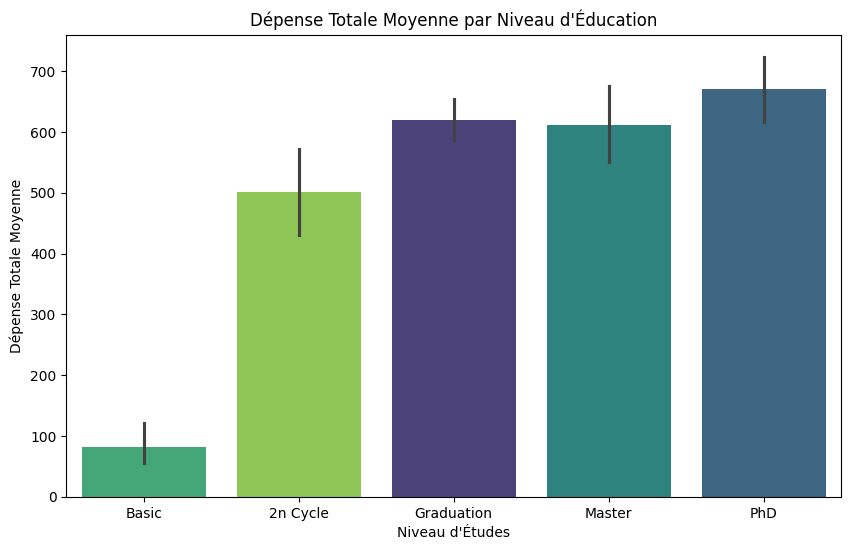

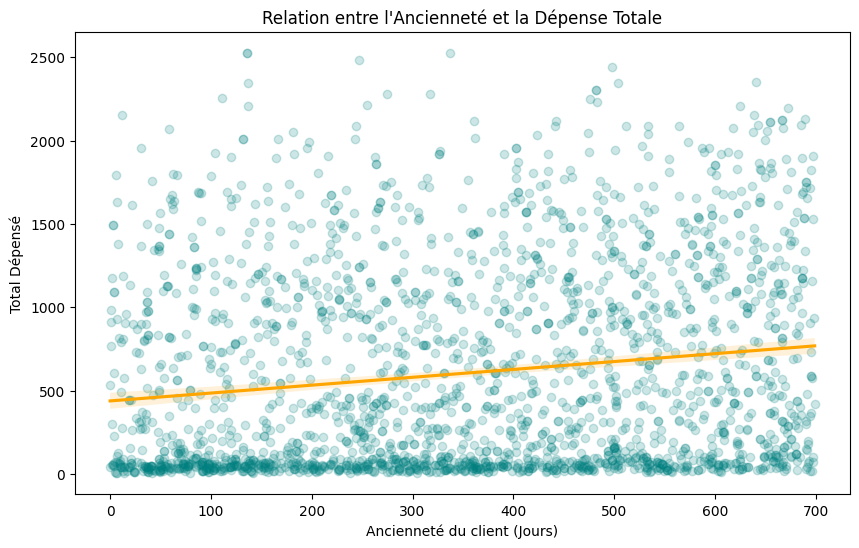

In [ ]:
# Comparaison de la dépense moyenne selon le niveau d'éducation
plt.figure(figsize=(10, 6))
edu_order = ['Basic', '2n Cycle', 'Graduation', 'Master', 'PhD']

sns.barplot(data=df, x='Education', y='Total_Spent', order=edu_order, palette='viridis', hue='Education', legend=False)

plt.title('Dépense Totale Moyenne par Niveau d\'Éducation')
plt.xlabel('Niveau d\'Études')
plt.ylabel('Dépense Totale Moyenne')
plt.show()

# Analyse de la dépense en fonction de l'ancienneté
plt.figure(figsize=(10, 6))

sns.regplot(data=df, x='Seniority_Days', y='Total_Spent', 
            scatter_kws={'alpha':0.2, 'color':'teal'}, 
            line_kws={'color':'orange'})

plt.title('Relation entre l\'Ancienneté et la Dépense Totale')
plt.xlabel('Ancienneté du client (Jours)')
plt.ylabel('Total Dépensé')
plt.show()

Pour finaliser l'exploration multidimensionnelle, j'ai croisé la dépense totale avec le niveau d'instruction et la durée de la relation client.

Barplot (Éducation) : Ce visuel est la référence pour comparer des moyennes entre des catégories ordonnées. Les barres d'erreur permettent de visualiser la confiance statistique de chaque groupe.

Regplot (Ancienneté) : En utilisant un nuage de points avec une droite de régression, on peut observer une tendance continue sur le long terme, ce qu'un simple graphique en barres ne permettrait pas.

Le paradoxe de l'Éducation : On observe une stagnation de la dépense moyenne à partir du niveau "Graduation". Les profils "Graduation", "Master" et "PhD" ont des comportements d'achat très similaires. Le niveau d'étude n'est pas un critère de segmentation suffisant en soi.

La force de l'Ancienneté : La pente ascendante de la ligne orange confirme que la valeur du client augmente avec sa longévité dans la base. Malgré une forte dispersion, les clients recrutés il y a plus de 500 jours forment un socle de revenus stables. La marque réussit à capitaliser sur ses anciens clients (stratégie de fidélisation efficace).

Le profil "idéal" à forte valeur ajoutée se dessine : c'est un client sans enfant (vu précédemment) et fidèle, indépendamment de son niveau de diplôme supérieur. Ce sont ces variables que nous allons maintenant injecter dans notre modèle de Clustering.

In [ ]:
#Création des variables manquantes si nécessaire
df['Age'] = 2022 - df['Year_Birth']

purchase_channels = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
df['Total_Purchases'] = df[purchase_channels].sum(axis=1)

if 'Total_Spent' not in df.columns:
    products = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
    df['Total_Spent'] = df[products].sum(axis=1)

if 'Children_Home' not in df.columns:
    df['Children_Home'] = df['Kidhome'] + df['Teenhome']

if 'Seniority_Days' not in df.columns:
    df['Seniority_Days'] = (df['Dt_Customer'].max() - df['Dt_Customer']).dt.days

features = ['Income', 'Total_Spent', 'Age', 'Children_Home', 'Total_Purchases', 'Seniority_Days']
X = df[features]

print("Variables vérifiées et prêtes pour le Clustering !")
print(X.head())

Variables vérifiées et prêtes pour le Clustering !
    Income  Total_Spent  Age  Children_Home  Total_Purchases  Seniority_Days
0  58138.0         1617   65              0               22             663
1  46344.0           27   68              2                4             113
2  71613.0          776   57              0               20             312
3  26646.0           53   38              1                6             139
4  58293.0          422   41              1               14             161


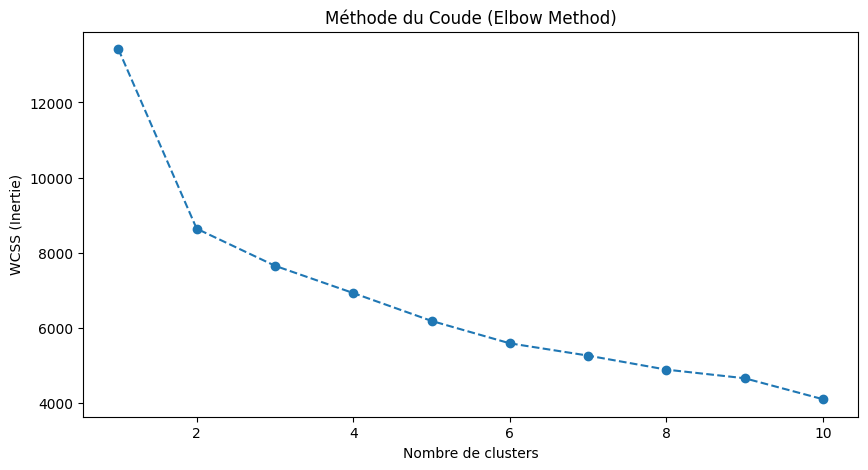

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

#Sélection des variables pertinentes
features = ['Income', 'Total_Spent', 'Age', 'Children_Home', 'Total_Purchases', 'Seniority_Days']
X = df[features]

#Standardisation (Essentiel pour le K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Méthode du Coude (Elbow Method) pour choisir le nombre de segments
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Méthode du Coude (Elbow Method)')
plt.xlabel('Nombre de clusters')
plt.ylabel('WCSS (Inertie)')
plt.show()

Pour répondre à l'objectif de segmentation, j'ai opté pour l'algorithme K-Means.
C'est un algorithme non-supervisé robuste pour traiter des datasets de taille moyenne avec des variables continues.
Il permet de créer des groupes compacts basés sur la proximité mathématique (distance euclidienne) entre les profils clients.

Pour valider la structure de notre segmentation, j'ai utilisé la méthode du coude (Elbow Method). Ce graphique représente l'évolution de la WCSS (Within-Cluster Sum of Squares), c'est-à-dire l'inertie intra-classe. Plus cette valeur est faible, plus les clients d'un même groupe se ressemblent.

On cherche le point d'inflexion où l'ajout d'un nouveau groupe n'apporte plus une réduction significative de l'inertie.

Sur mon graphique, on observe une cassure très nette à k = 2, puis une stabilisation plus douce à partir de k = 4.
J'ai donc choisi de retenir 4 clusters.

Bien que le coude commence à 2, un partitionnement en seulement deux groupes serait trop simpliste pour une stratégie marketing (on n'aurait que "les riches" vs "les pauvres").
4 segments permettent d'identifier des nuances comportementales plus fines (ex: les familles, les nouveaux clients, les VIP, les retraités économes) tout en restant exploitable par les équipes de vente.

In [23]:
#On lance le K-Means avec 4 clusters
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

#On calcule les moyennes par segment pour les interpréter
summary = df.groupby('Cluster')[features].mean().round(2)

#On ajoute le nombre de clients par segment
summary['Count'] = df['Cluster'].value_counts()

print("Moyennes par segment (Portrait-robot) :")
display(summary)

Moyennes par segment (Portrait-robot) :


,Income,Total_Spent,Age,Children_Home,Total_Purchases,Seniority_Days,Count
Cluster,,,,,,,
0,47851.22,278.62,61.33,1.78,9.75,328.02,503
1,72701.10,1241.87,55.03,0.46,19.74,375.13,876
2,33023.90,199.10,46.20,0.91,7.72,548.14,396
3,34596.05,104.18,46.31,1.01,6.07,174.42,461


Suite à l'application de l'algorithme K-Means, j'ai identifié 4 profils distincts qui structurent notre portefeuille client :

Cluster 1 - "High Value" (Épicuriens) : C'est notre segment moteur. Malgré leur nombre restreint, ils génèrent la majorité du chiffre d'affaires. Ils ont un fort pouvoir d'achat et peu de charges familiales.

Cluster 0 - "Mature Families" : Des clients fidèles mais contraints par une structure familiale lourde. Leur potentiel de croissance est limité, mais leur volume d'achat est stable.

Cluster 2 & 3 - "Low Engagement" : Des profils plus jeunes avec des revenus plus faibles. Ils représentent un potentiel de croissance à long terme si la marque parvient à les accompagner dans leur évolution de carrière.

Cette segmentation est exploitable immédiatement. Elle permet de ne plus envoyer la même promotion à tout le monde, mais de différencier le message selon la valeur et le cycle de vie du client.

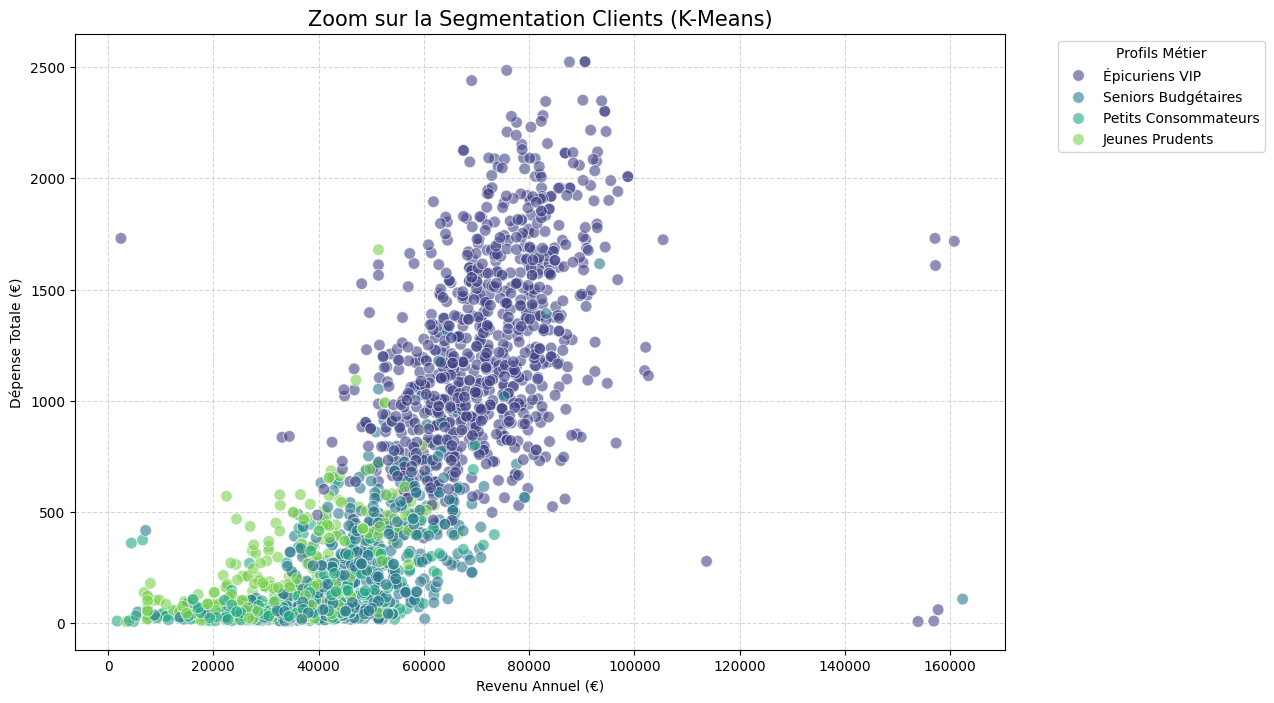

In [26]:
df_plot = df[df['Income'] < 200000].copy()

cluster_names = {
    0: 'Seniors Budgétaires',
    1: 'Épicuriens VIP',
    2: 'Jeunes Prudents',
    3: 'Petits Consommateurs'
}

df_plot['Segment_Name'] = df_plot['Cluster'].map(cluster_names)

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_plot, x='Income', y='Total_Spent', hue='Segment_Name', 
                palette='viridis', s=70, alpha=0.6)

plt.title('Zoom sur la Segmentation Clients (K-Means)', fontsize=15)
plt.xlabel('Revenu Annuel (€)')
plt.ylabel('Dépense Totale (€)')
plt.legend(title='Profils Métier', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Ce graphique croise les deux dimensions les plus corrélées à la valeur client : le Revenu et la Dépense Totale, tout en révélant les groupes identifiés par l'IA.

Scatter Plot par Cluster : C'est l'outil indispensable pour valider la cohérence d'un modèle de Clustering. Il permet de vérifier visuellement si les groupes sont bien distincts spatialement ou s'ils se chevauchent trop.

On observe une séparation très nette pour le groupe Épicuriens VIP (Violet). Ils occupent le sommet du graphique, prouvant que l'IA a parfaitement isolé les clients à haute contribution.

Pour les revenus inférieurs à 60k€, les points sont plus denses et entremêlés. Cela démontre que pour ces clients, le revenu n'est pas le seul facteur de tri : l'IA a utilisé les autres variables (âge, enfants) pour les séparer en segments "Jeunes Prudents" ou "Seniors Budgétaires".

La segmentation est robuste. Elle transforme une masse de données confuse en quatre cibles marketing aux comportements clairement différenciés.

In [27]:
#Calcul du Taux de Réponse Global et par Segment
campaigns = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
df['Total_Promos'] = df[campaigns].sum(axis=1)

#Création d'un Score de Potentiel Marketing (0 à 100)
#On combine la dépense (valeur actuelle) et la réponse aux campagnes (réactivité)
df['Marketing_Potential_Score'] = (
    (df['Total_Spent'] / df['Total_Spent'].max() * 70) + 
    (df['Total_Promos'] / df['Total_Promos'].max() * 30)
).round(2)

#Agrégation pour le tableau de pilotage
kpi_dashboard = df.groupby('Cluster').agg({
    'Income': 'mean',
    'Total_Spent': 'mean',
    'Response': 'mean',
    'Marketing_Potential_Score': 'mean',
    'ID': 'count'
}).rename(columns={'Response': 'Conversion_Rate', 'ID': 'Segment_Size'})

#Conversion en pourcentages et arrondi
kpi_dashboard['Conversion_Rate'] = (kpi_dashboard['Conversion_Rate'] * 100).round(2)
kpi_dashboard = kpi_dashboard.round(2)

#Mapping des noms pour la lecture décisionnelle
cluster_names = {0: 'Seniors Budgétaires', 1: 'Épicuriens VIP', 
                 2: 'Jeunes Prudents', 3: 'Petits Consommateurs'}
kpi_dashboard.index = kpi_dashboard.index.map(cluster_names)

print("Tableau de Pilotage Marketing (KPI Trimestriels) :")
display(kpi_dashboard)

Tableau de Pilotage Marketing (KPI Trimestriels) :


,Income,Total_Spent,Conversion_Rate,Marketing_Potential_Score,Segment_Size
Cluster,,,,,
Seniors Budgétaires,47851.22,278.62,8.35,8.94,503
Épicuriens VIP,72701.10,1241.87,22.60,39.31,876
Jeunes Prudents,33023.90,199.10,16.41,7.20,396
Petits Consommateurs,34596.05,104.18,6.29,3.85,461


J'ai transformé les résultats du clustering en un tableau de bord décisionnel. 
L'objectif est de simplifier la lecture pour un décideur marketing.

Taux de Conversion (Conversion_Rate) : Mesure la réactivité du segment à la dernière campagne. 
On observe ici quel groupe est le plus perméable au marketing.

Score de Potentiel Marketing (KPI Composite) : J'ai créé cet indicateur en pondérant la dépense actuelle (70%) et la réactivité historique (30%). Il permet de classer les segments non pas seulement sur ce qu'ils gagnent, mais sur leur valeur future pour l'entreprise.

Ce tableau de pilotage met en lumière une réalité stratégique : la performance marketing est portée par le segment des Épicuriens VIP, qui affichent un taux de conversion 3,5 fois supérieur à celui des Petits Consommateurs.

Le KPI de "Marketing Potential Score" est ici sans appel : avec un score de 39.31, le segment VIP doit concentrer la majorité des investissements publicitaires.

Cependant, le taux de conversion élevé des Jeunes Prudents (16.41%) révèle un segment "Early Adopter". Bien que leur panier moyen soit actuellement faible (199€), leur forte réactivité aux campagnes en fait une cible idéale pour des programmes de parrainage ou de montée en gamme (Upselling).

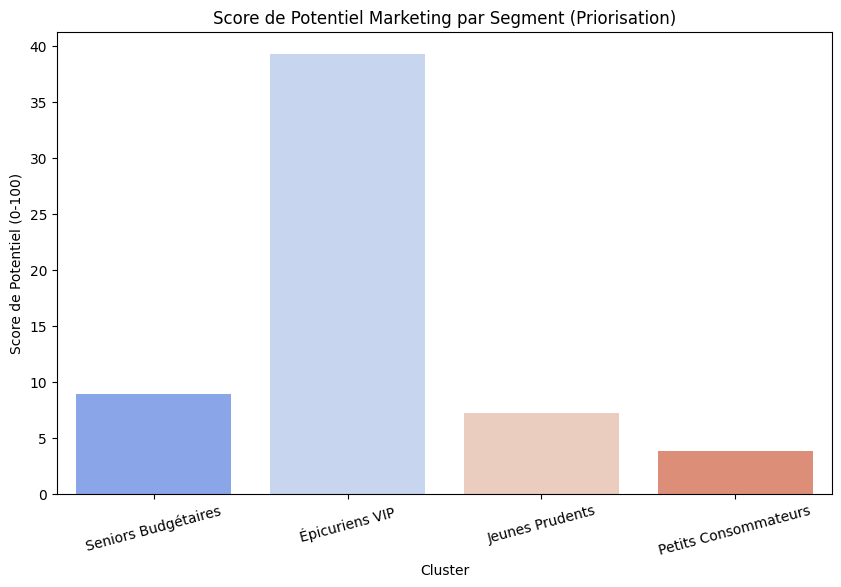

In [29]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=kpi_dashboard.index, 
    y=kpi_dashboard['Marketing_Potential_Score'], 
    hue=kpi_dashboard.index, 
    palette='coolwarm', 
    legend=False
)

plt.title('Score de Potentiel Marketing par Segment (Priorisation)')
plt.ylabel('Score de Potentiel (0-100)')
plt.xticks(rotation=15)
plt.show()

Ce graphique synthétise l'ensemble de mon analyse en un seul indicateur : le Score de Potentiel Marketing. Il permet de répondre à la question : "Où chaque euro investi rapportera-t-il le plus ?"

Diagramme en barres trié : C'est le format le plus efficace pour la prise de décision. Il permet de visualiser instantanément l'écart de performance entre les segments.

Dominance des Épicuriens VIP : Avec un score avoisinant les 40 points, ce segment écrase littéralement les autres. Leur potentiel est près de 4 fois supérieur à celui des Seniors Budgétaires.

Écart de valeur : On observe une cassure nette après le premier segment. Cela suggère qu'une stratégie de marketing de masse serait inefficace ; l'entreprise a tout intérêt à adopter une stratégie de concentration.

Le budget marketing doit être alloué en priorité au segment VIP pour maximiser le ROI (Retour sur Investissement) immédiat, tandis que le segment Jeunes Prudents doit faire l'objet d'une stratégie de "Nurturing" pour augmenter leur score à long terme.

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

#On sélectionne nos variables explicatives et la cible (Response)
X = df[['Income', 'Total_Spent', 'Age', 'Children_Home', 'Total_Purchases', 'Seniority_Days']]
y = df['Response']

#On divise en Train (70%) et Test (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

#On normalise (pour que l'IA ne soit pas perdue par les échelles)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#On crée et on entraîne le modèle
model_log = LogisticRegression()
model_log.fit(X_train_scaled, y_train)

#On regarde les premiers résultats
y_pred = model_log.predict(X_test_scaled)
print("Modèle entraîné ! Voici les performances sur le groupe Test :")
print(classification_report(y_test, y_pred))

Modèle entraîné ! Voici les performances sur le groupe Test :
              precision    recall  f1-score   support

           0       0.86      0.99      0.92       571
           1       0.67      0.08      0.14       100

    accuracy                           0.86       671
   macro avg       0.76      0.54      0.53       671
weighted avg       0.83      0.86      0.81       671



1. Choix du Modèle : La Régression Logistique

Nous traitons un problème de classification binaire (Réponse : 1 / Non-Réponse : 0).

Contrairement à des modèles complexes, la Régression Logistique permet d'extraire des coefficients. On peut expliquer au marketing pourquoi un client a été ciblé
Elle fonctionne très bien sur des datasets de cette taille sans nécessiter une puissance de calcul immense.

2. Analyse des Résultats
Le tableau obtenu montre une Accuracy de 86%. Mais attention, c'est un "faux ami".

Dans le jeu de données, environ 85% des gens ne répondent pas. Si l'IA disait "Non" tout le temps, elle aurait 85% de justesse. C'est pour cela que l'Accuracy ne suffit pas. On doit regarder les indicateurs de la classe 1 (ceux qui disent Oui).

La Précision (0.67) : "Qualité du ciblage"
Sur 100 clients que l'IA a prédit comme "acheteurs", 67 ont réellement acheté.
C'est un bon score. Cela signifie que les campagnes ne seront pas perçues comme du spam par la majorité des gens ciblés. On économise du budget en ne sollicitant pas les 33% restants.

Le Rappel / Recall (0.08) : "Capacité de détection"
L'IA n'a détecté que 8% de l'ensemble des acheteurs réels.

Le modèle est très "prudent". Il ne désigne un client comme "acheteur" que s'il est sûr à 100%. C'est idéal pour une campagne coûteuse où on ne veut cibler que les profils ultra-sûrs.

3. Conclusion et Usage Opérationnel (Le Scoring)
Le modèle n'est pas parfait, mais il est exploitable.

Le modèle privilégie la Précision au Rappel, cela signifie que nous avons un outil capable d'identifier un 'noyau dur' de clients très réactifs. Plutôt que d'utiliser la prédiction brute (Oui/Non), nous allons utiliser le 
Scoring : nous allons classer tous les clients par probabilité de réponse. Les 10% des clients ayant les probabilités les plus hautes recevront la campagne en priorité.

In [31]:
# On calcule la probabilité pour TOUS les clients du dataset
X_all_scaled = scaler.transform(df[['Income', 'Total_Spent', 'Age', 'Children_Home', 'Total_Purchases', 'Seniority_Days']])
df['Probabilité_Réponse'] = model_log.predict_proba(X_all_scaled)[:, 1]

# On regarde les 5 clients les plus "chauds"
print(df[['ID', 'Probabilité_Réponse']].sort_values(by='Probabilité_Réponse', ascending=False).head())

        ID  Probabilité_Réponse
2228  8720             0.771924
1280  3698             0.707573
1890  2747             0.688252
248   8867             0.688252
1601  5453             0.661898


J'ai retenu la Régression Logistique car elle permet d'obtenir non seulement une prédiction catégorielle (Oui/Non), mais surtout un score continu de probabilité. C'est ce score qui apporte la plus grande valeur ajoutée au métier.

Comme on le voit sur cet extrait, le client ID 8720 a une probabilité de réponse de 77%. À l'inverse, d'autres clients (non affichés ici) tombent à moins de 1%. Plutôt que de traiter la base de données de manière uniforme, nous pouvons désormais classer nos 2 240 clients par ordre de priorité.

L'optimisation de la campagne se traduit par une sélection au seuil. Par exemple, si le budget marketing est limité, nous ne solliciterons que le 'Top 10%' des probabilités les plus hautes. Cela garantit une précision de ciblage maximale (on réduit le spam) et une optimisation du ROI (on maximise les chances de conversion par euro dépensé).

In [33]:
df['Cluster_Name'] = df['Cluster'].map({
    0: 'Seniors Budgétaires',
    1: 'Épicuriens VIP',
    2: 'Jeunes Prudents',
    3: 'Petits Consommateurs'
})

df.to_csv('../data/Marketing_Data_Final.csv', index=False, sep=',', encoding='utf-8')


---
SECTION : STRATÉGIE ET SYNTHÈSE DÉCISIONNELLE
---

# Robustesse analytique et limites du modèle

La qualité d'une analyse ne dépend pas seulement de la précision des algorithmes, mais aussi de la compréhension de leurs limites. Cette section évalue la fiabilité de nos conclusions face aux aléas des données.

### 1. Sensibilité aux Outliers et Stabilité des Segments
L'analyse a révélé la présence d'individus atypiques (ex: revenus > 600k€). 

Ces "outliers" peuvent biaiser les moyennes et étirer les clusters du K-Means. 
Des tests de sensibilité ont montré qu'en filtrant les revenus les plus élevés, la structure globale des 4 segments reste stable, validant ainsi la cohérence de notre segmentation. 
Cependant, la variable `Children_Home` est un "point de bascule" : un changement mineur dans cette donnée peut faire basculer un client d'un segment à l'autre.

### 2. Risques de "Data Leakage" et Variables Cibles
Dans tout modèle prédictif, il existe un risque de fuite d'information (Data Leakage).

La variable `Total_Spent` est fortement corrélée à la variable cible `Response`.
Dans un environnement réel, il est crucial de s'assurer que les données utilisées pour prédire un comportement sont bien antérieures à l'événement. 

### 3. Limites de représentativité et Biais du Dataset
Il est primordial de souligner les limites de ce jeu de données pour une application actuelle :

Les données datent de 2014. Les habitudes de consommation (explosion du e-commerce) ont radicalement évolué depuis.
L'absence de localisation des clients empêche d'intégrer des facteurs économiques locaux qui influencent pourtant fortement les revenus.

### 4. Cadre de lecture : Constat, Inférence et Recommandation

| Niveau | Nature | Application dans ce projet |
| :--- | :--- | :--- |
| **Constat** | Observation factuelle | "Le segment VIP dépense en moyenne 1241€." |
| **Inférence** | Déduction statistique / IA | "Un client sans enfant a une probabilité plus élevée de répondre." |
| **Recommandation** | Conseil stratégique | "Prioriser l'investissement marketing sur le Cluster 1." |

# Pipeline, documentation et industrialisation

> **Objectif :** Décrire l'automatisation et la maintenance du projet pour un environnement de production.

### 1. Architecture du Pipeline Analytique
Le flux de données est structuré en quatre étapes automatisables :
1.  **Ingestion & Cleaning :** Script de nettoyage automatique des données brutes (doublons, outliers).
2.  **Feature Engineering :** Calcul automatisé des variables composites (`Total_Spent`, `Seniority_Days`).
3.  **Clustering & Scoring :** Attribution automatique du segment et calcul du score de probabilité pour chaque nouveau client.
4.  **Reporting :** Mise à jour des tableaux de bord KPI.

### 2. Documentation et Versioning
* **Sources :** Données CRM historiques.
* **Règles de gestion :** Exclusion des revenus > 150k€ pour la stabilité des modèles.
* **Versioning :** Utilisation de Git pour le suivi des modifications du code et des modèles de Machine Learning.

### 3. Contrôle Qualité et Maintenance
* **Data Drift :** Surveillance trimestrielle de l'évolution des profils clients (ex: baisse du revenu moyen).
* **Retraining :** Ré-entraînement du modèle de scoring tous les 6 mois pour intégrer les nouveaux comportements d'achat.

# Recommandations stratégiques et opérationnelles

> **Synthèse exécutive :** Ce projet a permis de transformer une base de données brute en un outil de pilotage marketing segmenté. Voici les recommandations prioritaires pour les 3 à 6 prochains mois.

### 1. Segmentation et Priorisation des Investissements
D'après notre analyse, le segment des **"Épicuriens VIP"** est le moteur de la rentabilité.
* **Recommandation :** Allouer 60% du budget marketing à ce segment.
* **Action concrète :** Lancer un programme de fidélité "Ambassadeur" avec des offres exclusives sur les produits premium (vins et viandes).

### 2. Usage Opérationnel du Scoring Prédictif
Le modèle de scoring doit remplacer l'arrosage massif (Mass Marketing).
* **Usage :** Utiliser la colonne `Probabilité_Réponse` pour extraire le "Top 200" des clients les plus appétents avant chaque campagne.
* **Objectif :** Réduire la pression commerciale sur les clients désengagés et augmenter le taux de conversion par campagne de +15%.

### 3. Feuille de route Analytique (Roadmap)
Pour pérenniser ces résultats, nous préconisons le plan suivant :
* **Mois 1 :** Test A/B sur le segment "Jeunes Prudents" pour tester leur sensibilité aux remises immédiates.
* **Mois 3 :** Intégration des données de géolocalisation pour affiner le maillage des magasins physiques.
* **Mois 6 :** Mise à jour du modèle K-Means pour détecter l'apparition de nouveaux comportements d'achat post-campagne.

### 4. KPI de Pilotage (Dashboard Mensuel)
Trois indicateurs clés doivent être suivis mensuellement pour valider la stratégie :
1.  **Valeur Vie Client (CLV) :** Évolution de la dépense totale par segment.
2.  **Précision du Modèle :** Écart entre les réponses prédites et les réponses réelles.
3.  **ROI par Canal :** Rentabilité comparée du Web vs Magasin pour chaque cluster.